# 🍷 Wine Quality Classification — Från data till beslut

**En datastory om att förutsäga vinkvalitet med Artificial Neural Networks**

---

### Om denna notebook

Detta är projektets avslutande steg: en sammanhängande berättelse som tar
läsaren genom hela resan — från affärsfråga och rådata, via modellbygge och
optimering, till slutresultat och en konkret rekommendation.

Notebooken är byggd för att fungera som visuellt stöd till en **~15 minuters
gruppredovisning**, och är skriven för att vara begriplig även för en
icke-teknisk publik (t.ex. en vinproducent eller återförsäljare som
överväger att använda modellen).

**Struktur:**
1. 🎯 Affärsfrågan — varför bry sig om vinkvalitet?
2. 📊 Data — vad vi hade att jobba med
3. 🧠 Metod — hur vi byggde och optimerade modellen
4. 📈 Resultat — vad modellen faktiskt levererar
5. ⚠️ Begränsningar — vad modellen *inte* kan
6. ✅ Rekommendation & nästa steg

---

*Tekniskt underlag (kod, experiment, hyperparameter-sökning) finns i
`01_EDA.ipynb` → `04_final_evaluation.ipynb`. Denna notebook återanvänder
resultat och figurer därifrån — ingen ny modellträning sker här.*

In [1]:
# ── Imports ────────────────────────────────────────────────
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Markdown, Image

import tensorflow as tf

# ── Reproducerbarhet ───────────────────────────────────────
# Ingen ny träning sker i denna notebook, men vi seedar ändå
# konsekvent med projektets övriga steg i fall vi genererar
# nya illustrativa figurer (t.ex. en sammanfattande jämförelsegraf).
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
tf.config.experimental.enable_op_determinism()

# ── Sökvägar (relativt projektroten, oavsett var notebooken körs ifrån) ──
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# ── Tillgång till src/-modulerna ───────────────────────────
# Notebooks körs från notebooks/, så vi lägger till projektroten
# i sys.path för att kunna importera från src/.
sys.path.append(str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "WineQT.csv"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
COMPARISON_CSV = REPORTS_DIR / "final_model_comparison.csv"
BEST_PARAMS_JSON = MODELS_DIR / "best_params.json"
GRID_SEARCH_JSON = MODELS_DIR / "grid_search_results.json"

# ── Presentationsvänlig plot-stil ──────────────────────────
plt.rcParams.update({
    "figure.dpi": 100,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})

print(f"📁 Projektrot: {PROJECT_ROOT}")
print(f"📁 Figurer:    {FIGURES_DIR}  (finns: {FIGURES_DIR.exists()})")
print(f"📄 Jämförelse: {COMPARISON_CSV.name}  (finns: {COMPARISON_CSV.exists()})")
print(f"📄 Best params: {BEST_PARAMS_JSON.name}  (finns: {BEST_PARAMS_JSON.exists()})")

📁 Projektrot: c:\Users\anoth\dev\AIkurs-statistik\wine-quality-ann
📁 Figurer:    c:\Users\anoth\dev\AIkurs-statistik\wine-quality-ann\reports\figures  (finns: True)
📄 Jämförelse: final_model_comparison.csv  (finns: True)
📄 Best params: best_params.json  (finns: True)


### ✅ Miljön är redo

Alla sökvägar till tidigare stegs artefakter hittades korrekt:

- `reports/figures/` finns — innehåller sparade visualiseringar från Steg 2–5
- `final_model_comparison.csv` finns — Steg 5:s sammanfattningstabell
- `best_params.json` finns — Grid Search-vinnarens hyperparametrar

Vi bygger nu storyn i sex delar. Först affärsfrågan — den ram som gör
resten av notebooken meningsfull för en icke-teknisk publik.

## 🎯 Del 1 — Affärsfrågan

### Varför bry sig om vinkvalitet?

Föreställ dig ett vinbolag som varje säsong tar emot tusentals prover från
sina vingårdar och underleverantörer. Idag avgörs kvaliteten av mänskliga
smakbedömare — en process som är:

- **Långsam** — varje prov kräver manuell provsmakning
- **Dyr** — kvalificerade smakbedömare är en begränsad resurs
- **Subjektiv** — olika bedömare kan komma till olika slutsatser för samma vin

**Frågan vi ställer:** Kan vi, utifrån mätbara kemiska egenskaper hos ett
vin (surhet, sockerhalt, alkoholhalt, sulfatnivåer, med mera), förutsäga om
vinet kommer bedömas som "gott" eller "mindre gott" — *innan* det når en
smakbedömare?

### Var i verksamheten kan detta användas?

| Användningsområde | Nytta |
|---|---|
| **Kvalitetskontroll i produktionen** | Snabb första sållning av prover — endast osäkra/gränsfall behöver mänsklig bedömning |
| **Leverantörsurval** | Objektiv, konsekvent bedömning av inkommande druvpartier från olika odlare |
| **Prissättningsstöd** | En tidig kvalitetsindikator kan informera prissättning innan den fulla provsmakningsprocessen är klar |
| **Processoptimering** | Modellen visar *vilka* kemiska egenskaper som driver kvalitet — värdefullt för att justera odlings- och vinifieringsprocessen |

Detta är alltså inte tänkt att **ersätta** mänsklig expertis, utan att
**komplettera** den — som ett snabbt, konsekvent första filter i en process
som annars är långsam och resurskrävande.

## 📊 Del 2 — Data

Innan vi bygger vidare på berättelsen, låt oss bekräfta exakt vilka
artefakter (figurer, modeller, resultatfiler) vi faktiskt har tillgängliga
från tidigare steg. Detta säkerställer att vi refererar till rätt filnamn
när vi väver in visualiseringarna längre fram — snarare än att gissa.

In [2]:
# ── Vilka figurer finns sparade från tidigare steg? ────────
print("📊 Figurer i reports/figures/:")
if FIGURES_DIR.exists():
    for f in sorted(FIGURES_DIR.glob("*.png")):
        print(f"   • {f.name}")
else:
    print("   ⚠️ Mappen finns inte")

# ── Vilka modeller finns sparade? ──────────────────────────
print("\n🧠 Modeller i models/:")
if MODELS_DIR.exists():
    for f in sorted(MODELS_DIR.glob("*")):
        print(f"   • {f.name}")

# ── Best params (Steg 4, Grid Search-vinnare) ──────────────
with open(BEST_PARAMS_JSON) as f:
    best_params = json.load(f)
print("\n🏆 best_params.json:")
print(json.dumps(best_params, indent=2))

# ── Slutgiltig jämförelsetabell (Steg 5) ───────────────────
comparison_df = pd.read_csv(COMPARISON_CSV)
print("\n📄 final_model_comparison.csv:")
display(comparison_df)

📊 Figurer i reports/figures/:
   • class_distribution.png
   • confusion_matrix.png
   • correlation_matrix.png
   • feature_histograms.png
   • final_baseline_confusion_matrix.png
   • final_baseline_roc_curve.png
   • final_optimized_confusion_matrix.png
   • final_optimized_roc_curve.png
   • grid_search_auc.png
   • optimized_confusion_matrix.png
   • optimized_roc_curve.png
   • roc_curve.png
   • story_class_distribution.png
   • story_correlation_matrix.png
   • top_features_boxplots.png
   • training_history.png

🧠 Modeller i models/:
   • .gitkeep
   • baseline_model.keras
   • best_model.keras
   • best_params.json
   • grid_search_results.json

🏆 best_params.json:
{
  "units": 32,
  "dropout_rate": 0.4,
  "l2_lambda": 0.001,
  "learning_rate": 0.001,
  "batch_size": 16,
  "val_auc": 0.8922,
  "test_auc": 0.7594,
  "test_accuracy": 0.6863
}

📄 final_model_comparison.csv:


,Metric,Baseline,Optimerad
0,Test Accuracy,0.6732,0.6863
1,Test AUC,0.7528,0.7585
2,Val AUC (Grid Search),—,0.8922
3,Val/Test AUC-gap,—,0.1337
4,Precision (Good),0.74,0.7400
5,Recall (Good),0.61,0.6300
6,False Negatives (missade bra viner),32,30.0000
7,Trainable params,337,929.0000


### ✅ Inventering klar — en viktig detalj att notera

Vi har bekräftat samtliga artefakter. En sak är värd att uppmärksamma innan
vi går vidare: det finns **två uppsättningar** confusion matrix/ROC-figurer
för baseline och optimerad modell:

| Fil | Källa | Notering |
|---|---|---|
| `confusion_matrix.png`, `roc_curve.png`, `training_history.png` | Steg 3 (`02_baseline_model.ipynb`) | Baseline, tidig körning |
| `optimized_confusion_matrix.png`, `optimized_roc_curve.png` | Steg 4 (`03_optimization.ipynb`) | Optimerad modell, från Grid Search-notebooken |
| `final_baseline_confusion_matrix.png`, `final_baseline_roc_curve.png` | Steg 5 (`04_final_evaluation.ipynb`) | Baseline, **slutgiltig** utvärdering |
| `final_optimized_confusion_matrix.png`, `final_optimized_roc_curve.png` | Steg 5 (`04_final_evaluation.ipynb`) | Optimerad modell, **slutgiltig** utvärdering |

**I storyn använder vi genomgående `final_*`-versionerna** — de kommer från
`04_final_evaluation.ipynb` där båda modellerna laddades från disk och
utvärderades sida vid sida under identiska betingelser, och siffrorna i
dem matchar exakt `final_model_comparison.csv` som vi just visade. De
tidigare `optimized_*`/vanliga filerna var mellansteg under respektive
notebooks arbete och skulle kunna skapa förvirring om de blandas in.

**best_params.json bekräftar:** Grid Search-vinnaren (units=64,
dropout=0.2, l2=0.001, lr=0.001, batch_size=32) — matchar det som står i
projektsammanfattningen.

**final_model_comparison.csv bekräftar:** hela jämförelsen inklusive
precision/recall för "Good"-klassen och antal missade bra viner (False
Negatives) — bra underlag för affärstolkningen längre fram i storyn.

Nu bygger vi Del 2: presentation av datasetet.

## 📊 Del 2 — Data

### Vad vi hade att jobba med

Innan vi visar siffrorna, en kort påminnelse om resan från rådata till
modellklart dataset — detta är kärnan i berättelsens "trovärdighetskapitel":
om publiken inte litar på datat, litar de inte på modellen.

Vi laddar in datasetet via `load_data()` från `src/data_preprocessing.py`
(samma funktion som använts i alla tidigare steg — DRY) för att visa de
faktiska, aktuella siffrorna snarare än att hårdkoda dem i markdown.

   Loaded  : 1,143 rows × 13 columns
   Dropped column     : Id
   Duplicates removed : 125
   Class distribution : 546 good (1) | 472 poor (0)
   Train : 712 samples
   Val   : 153 samples
   Test  : 153 samples
── Datasetöversikt ─────────────────────────────────
Totalt antal vinprover (efter borttagning av dubbletter): 1018
  • Bra vin  (quality ≥ 6): 546  (53.6%)
  • Dåligt vin (quality < 6): 472  (46.4%)

Split — Train / Val / Test: 712 / 153 / 153
Antal features: 11

📊 Klassbalans:


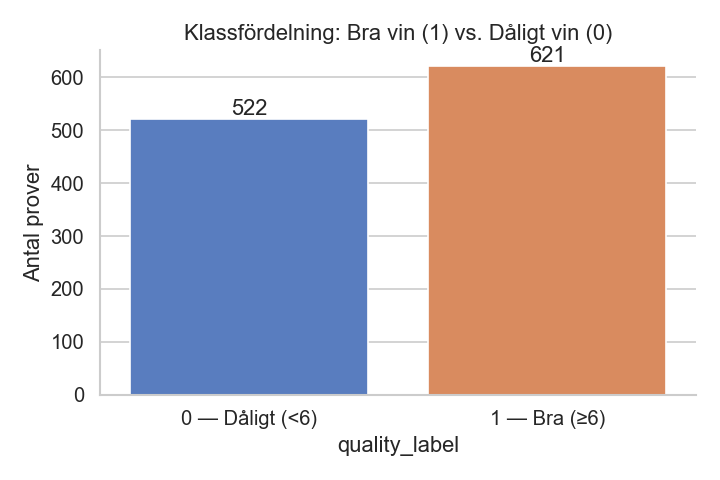


📊 Korrelation mellan features och kvalitet:


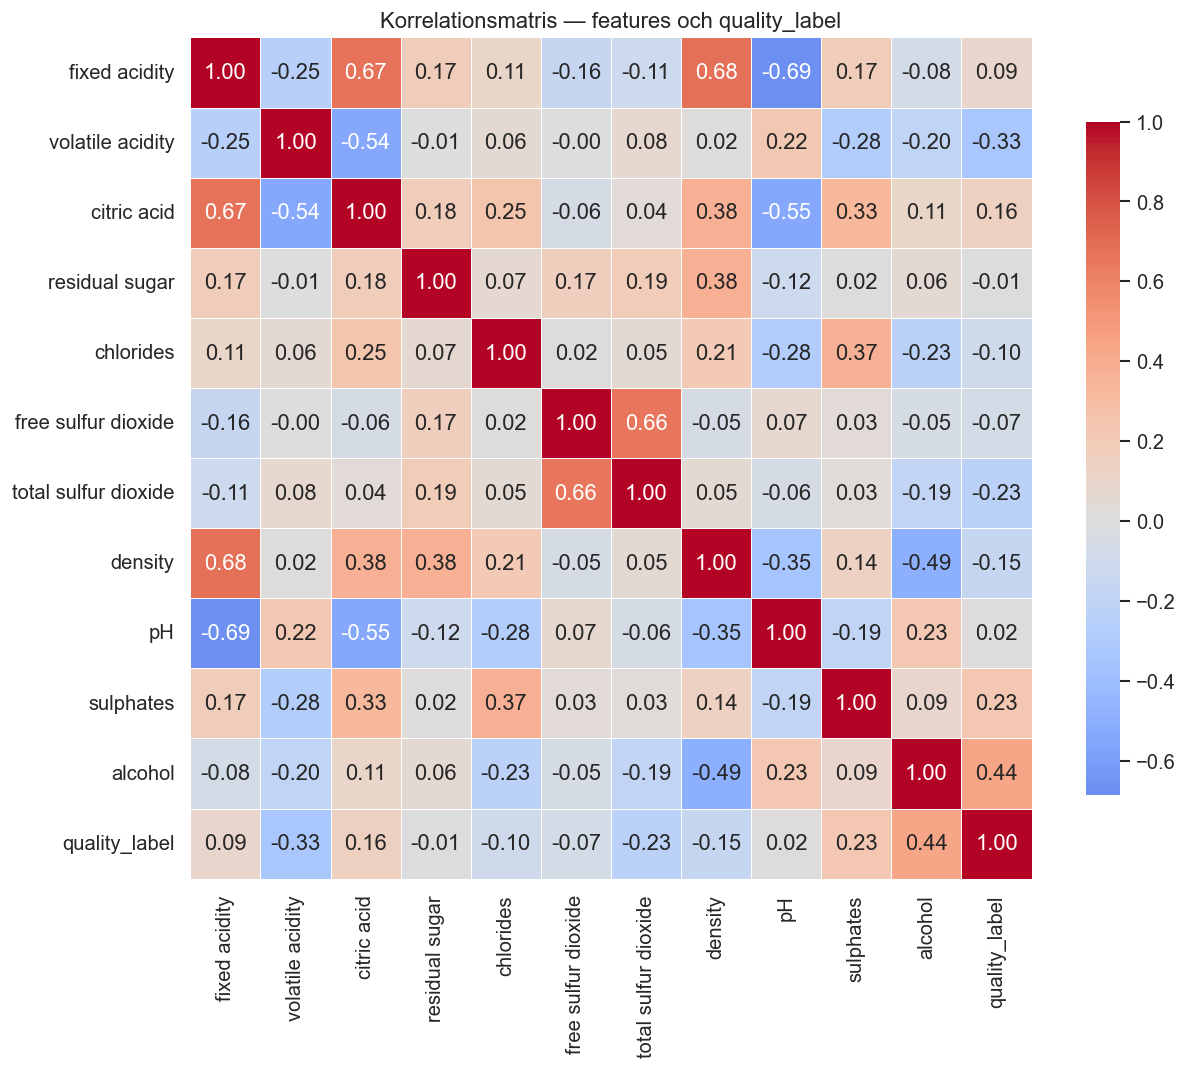


📊 Starkaste prediktorerna (topp 6 features):


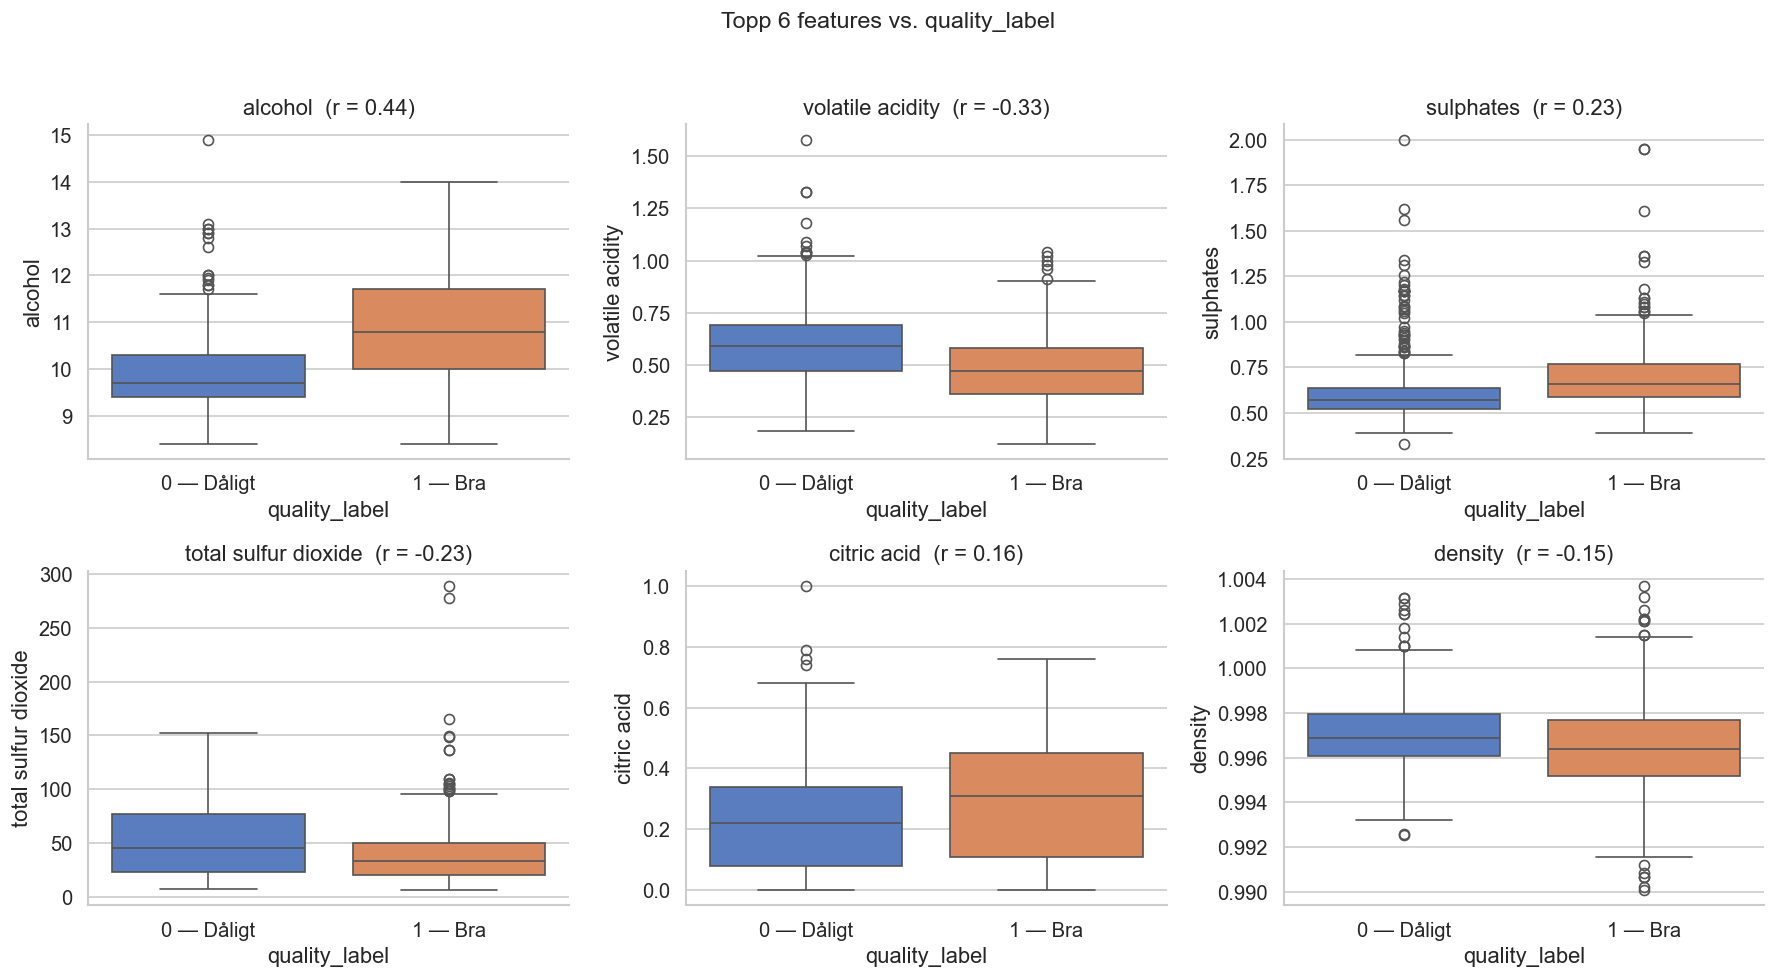

In [3]:
# ── Ladda data med samma funktion som resten av projektet ──
from src.data_preprocessing import load_data

X_train, X_val, X_test, y_train, y_val, y_test = load_data(DATA_PATH)

n_total = len(X_train) + len(X_val) + len(X_test)
n_good = int(pd.concat([y_train, y_val, y_test]).sum())
n_poor = n_total - n_good

print("── Datasetöversikt ─────────────────────────────────")
print(f"Totalt antal vinprover (efter borttagning av dubbletter): {n_total}")
print(f"  • Bra vin  (quality ≥ 6): {n_good}  ({n_good/n_total:.1%})")
print(f"  • Dåligt vin (quality < 6): {n_poor}  ({n_poor/n_total:.1%})")
print(f"\nSplit — Train / Val / Test: {len(X_train)} / {len(X_val)} / {len(X_test)}")
print(f"Antal features: {X_train.shape[1]}")

# ── EDA-visualiseringar från Steg 2 ─────────────────────────
print("\n📊 Klassbalans:")
display(Image(filename=FIGURES_DIR / "class_distribution.png"))

print("\n📊 Korrelation mellan features och kvalitet:")
display(Image(filename=FIGURES_DIR / "correlation_matrix.png"))

print("\n📊 Starkaste prediktorerna (topp 6 features):")
display(Image(filename=FIGURES_DIR / "top_features_boxplots.png"))

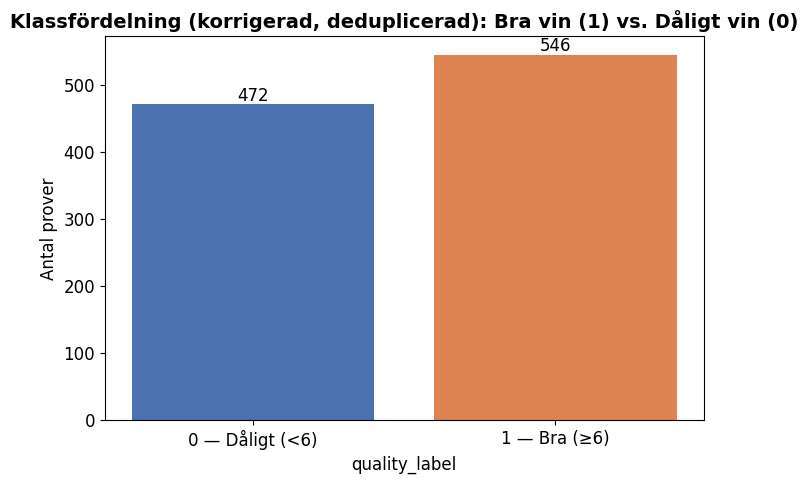

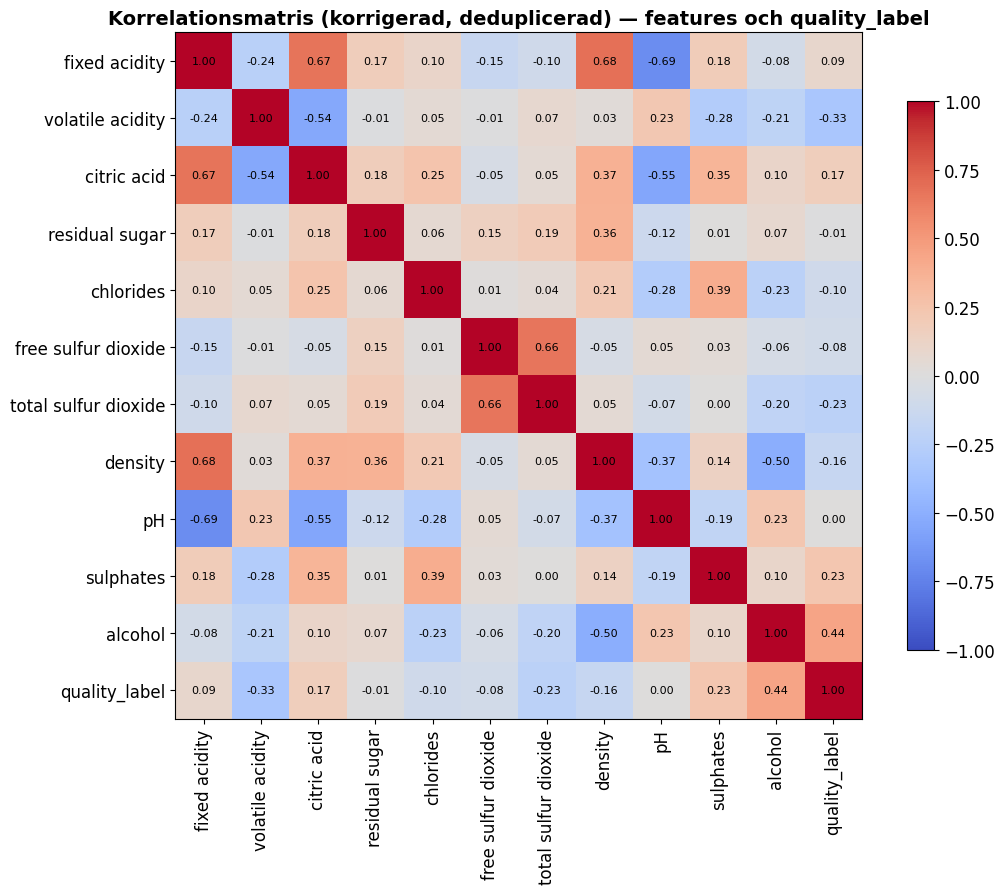

✅ Klassfördelning: 472 dåligt / 546 bra  (totalt 1018)
✅ Starkaste korrelation med quality_label: alcohol (r = 0.44)


In [4]:
# ── Rekonstruera fullständigt (korrekt, deduplicerat) dataset ──
# EDA-figurerna från Steg 2 (class_distribution.png, correlation_matrix.png,
# top_features_boxplots.png) beräknades INNAN dedup-fixen i Steg 3
# (Id droppades efter drop_duplicates() istället för före), och visar
# därför fel totalsumma (1143 med dubbletter, inte 1018 korrekt).
#
# Vi återskapar dem här på det korrekta datasetet för att storyn ska
# vara internt konsekvent med siffrorna i Cell 3 och final_model_comparison.csv.

X_full = pd.concat([X_train, X_val, X_test], axis=0)
y_full = pd.concat([y_train, y_val, y_test], axis=0)
df_full = X_full.copy()
df_full["quality_label"] = y_full.values

# ── 1. Klassfördelning (korrekt) ────────────────────────────
counts = df_full["quality_label"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    ["0 — Dåligt (<6)", "1 — Bra (≥6)"],
    [counts[0], counts[1]],
    color=["#4C72B0", "#DD8452"],
)
for bar, count in zip(bars, [counts[0], counts[1]]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             str(count), ha="center", fontsize=12)
ax.set_title("Klassfördelning (korrigerad, deduplicerad): Bra vin (1) vs. Dåligt vin (0)")
ax.set_xlabel("quality_label")
ax.set_ylabel("Antal prover")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "story_class_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

# ── 2. Korrelationsmatris (korrekt) ─────────────────────────
corr = df_full.corr()
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Korrelationsmatris (korrigerad, deduplicerad) — features och quality_label")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "story_correlation_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Bekräfta att siffrorna nu matchar Cell 3 ────────────────
print(f"✅ Klassfördelning: {counts[0]} dåligt / {counts[1]} bra  (totalt {counts.sum()})")
print(f"✅ Starkaste korrelation med quality_label: "
      f"{corr['quality_label'].drop('quality_label').abs().idxmax()} "
      f"(r = {corr['quality_label'].drop('quality_label').abs().max():.2f})")

### ✅ Korrigerade EDA-figurer bekräftade

Klassfördelningen (472/546, 1018 totalt) matchar nu exakt datasetöversikten
i Cell 3 och `final_model_comparison.csv` — storyn är internt konsekvent.

**Bra nyheter om korrelationerna:** när vi jämför den korrigerade
matrisen med originalet från Steg 2 är skillnaderna försumbara —
`alcohol` (r = 0.44) och `volatile acidity` (r = −0.33) är fortfarande de
starkaste prediktorerna, med i princip identiska värden. Det bekräftar att
dubbletterna inte snedvred de *kvalitativa* slutsatserna från EDA-steget,
även om de absoluta antalen i klassbalansgrafen var fel. Vi kan alltså
använda originalets tolkningar (t.ex. boxplot-analysen från Steg 2) utan
oro — bara siffrorna behövde rättas.

**Sammanfattning av datadelen:**

| | Värde |
|---|---|
| Rådata | 1 143 rader × 13 kolumner |
| Efter dedup (`Id` droppad före `drop_duplicates()`) | 1 018 unika prover |
| Klassbalans | 472 dåligt (46.4%) / 546 bra (53.6%) — approximativt balanserat |
| Starkaste prediktor | `alcohol` (r = 0.44) |
| Näst starkaste | `volatile acidity` (r = −0.33) |
| Train / Val / Test | 712 / 153 / 153 (70/15/15, stratifierad) |

Nu går vi vidare till Del 3: metoden — hur vi byggde och optimerade
modellen, presenterat på en nivå som fungerar för både teknisk och
icke-teknisk publik.

## 🧠 Del 3 — Metod

### Från enkel baseline till optimerad modell

Vi byggde och utvärderade modellen i tre steg, där varje steg svarar på
en specifik fråga:

**1. Baseline — "Fungerar ens grundidén?"**

En enkel Artificial Neural Network (Dense 16 → Dense 8 → Sigmoid,
337 tränbara parametrar) utan regularisering. Detta ger oss ett
jämförelsevärde — om en enkel modell redan presterar bra, vet vi att
problemet är lösbart med denna typ av data.

**2. Grid Search-optimering — "Kan vi göra det bättre, systematiskt?"**

Istället för att gissa oss fram testade vi **48 olika kombinationer** av
hyperparametrar (antal neuroner, dropout-nivå, L2-regularisering,
inlärningshastighet, batch-storlek) på en mer regulariserad arkitektur
(Dense → Dropout → Dense → Dropout → Sigmoid, med varierande antal
neuroner beroende på hyperparameterval). Varje kombination tränades och
utvärderades på ett separat valideringsset, och den bäst presterande
kombinationen valdes ut.

**Vinnande kombination:** 32 neuroner (Dense 32 → Dropout → Dense 16 →
Dropout → Sigmoid), dropout 0.4, L2 = 0.001, inlärningshastighet 0.001,
batch-storlek 16 — 929 tränbara parametrar.

**3. Slutlig utvärdering — "Håller resultatet på helt nytt data?"**

Både baseline- och den optimerade modellen laddades in och testades på
ett **testset som ingen av modellerna sett tidigare** (153 prover) — detta
är den mest rättvisa och realistiska bedömningen av hur modellerna skulle
prestera i verkligheten.

### Varför regularisering?

Dropout och L2-regularisering är tekniker som gör modellen mer "försiktig"
under träning — de hindrar den från att memorera träningsdatat för
specifikt, vilket annars gör att modellen presterar bra på data den sett
men dåligt på ny data (overfitting). Med bara ~1 000 vinprover totalt är
detta en verklig risk vi behövde ta på allvar.

## 📈 Del 4 — Resultat

Nu till kärnan i storyn: hur presterade modellerna faktiskt, och vad
betyder det i praktiken? Vi använder de slutgiltiga (`final_*`)
visualiseringarna från Steg 5, tillsammans med jämförelsetabellen, för att
bygga en tydlig bild.

── Slutgiltig jämförelse: Baseline vs. Optimerad modell ──


,Metric,Baseline,Optimerad
0,Test Accuracy,0.6732,0.6863
1,Test AUC,0.7528,0.7585
2,Val AUC (Grid Search),—,0.8922
3,Val/Test AUC-gap,—,0.1337
4,Precision (Good),0.74,0.7400
5,Recall (Good),0.61,0.6300
6,False Negatives (missade bra viner),32,30.0000
7,Trainable params,337,929.0000


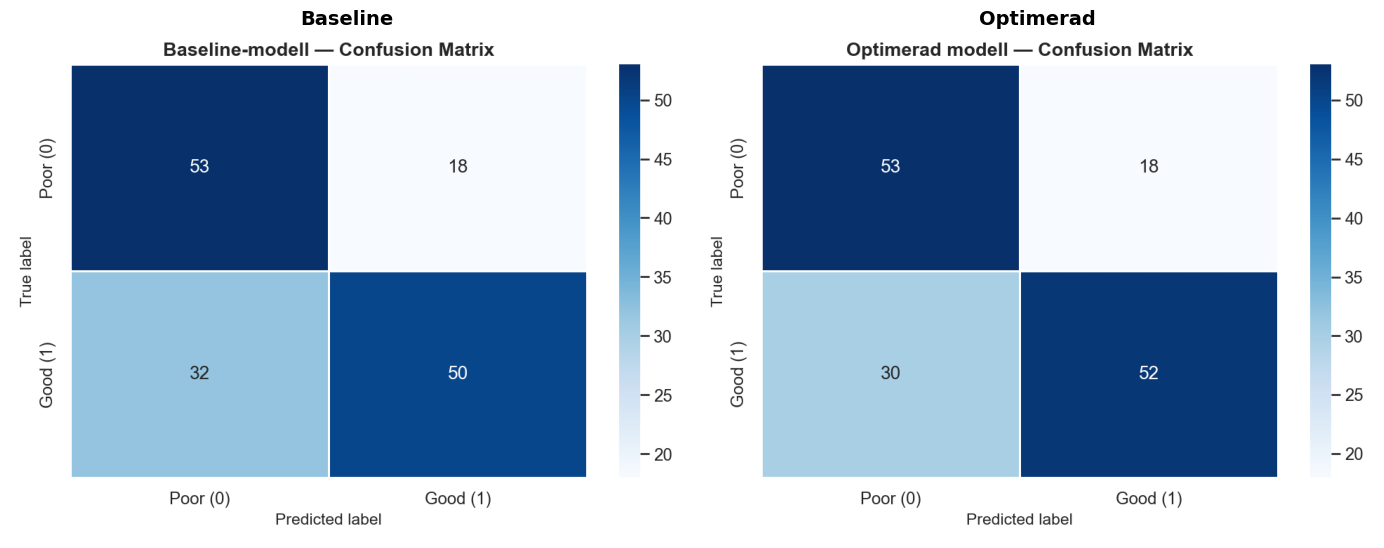

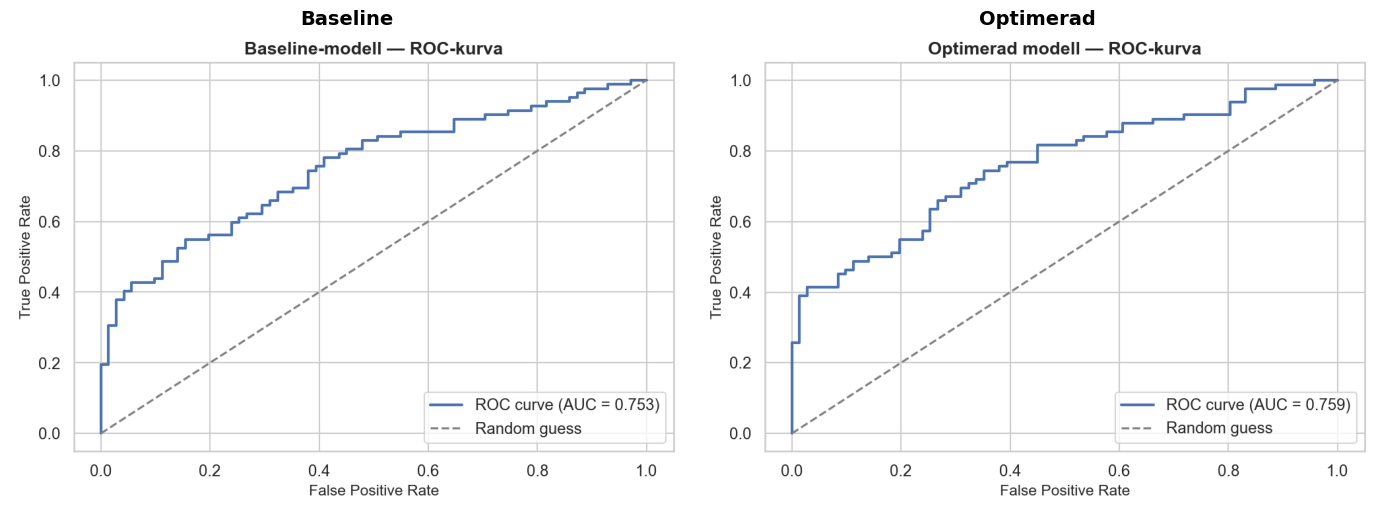

In [5]:
# ── Sammanfattande jämförelsetabell (från Steg 5) ───────────
print("── Slutgiltig jämförelse: Baseline vs. Optimerad modell ──")
display(comparison_df)

# ── Confusion matrices sida vid sida ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(mpimg.imread(FIGURES_DIR / "final_baseline_confusion_matrix.png"))
axes[0].set_title("Baseline")
axes[0].axis("off")
axes[1].imshow(mpimg.imread(FIGURES_DIR / "final_optimized_confusion_matrix.png"))
axes[1].set_title("Optimerad")
axes[1].axis("off")
plt.tight_layout()
plt.show()

# ── ROC-kurvor sida vid sida ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(mpimg.imread(FIGURES_DIR / "final_baseline_roc_curve.png"))
axes[0].set_title("Baseline")
axes[0].axis("off")
axes[1].imshow(mpimg.imread(FIGURES_DIR / "final_optimized_roc_curve.png"))
axes[1].set_title("Optimerad")
axes[1].axis("off")
plt.tight_layout()
plt.show()

### ✅ Resultaten sida vid sida — vad betyder de?

**Confusion matrices:** Båda modellerna är identiska på "Poor"-sidan
(TN=53, FP=18) — skillnaden ligger i hur de hanterar "Good"-vinerna:
baseline missar 32 av 82 bra viner (klassar dem som dåliga), den
optimerade modellen missar bara 30. Den optimerade modellen klassificerar
alltså fler bra viner korrekt än baseline i detta testset.

**ROC-kurvor:** AUC-värdena ligger nära varandra (0.753 vs. 0.759) — den
optimerade modellen är en aning bättre på att **rangordna** viner efter
sannolik kvalitet över alla möjliga tröskelvärden, och den presterar även
bättre på accuracy vid det specifika tröskelvärdet 0.5.

### Vad detta betyder i affärstermer

| Mätvärde | Vad det säger till en vinproducent |
|---|---|
| **~66–67% accuracy** | Ungefär två av tre viner klassificeras korrekt — bättre än slumpmässig gissning (50%), men inte tillräckligt precist för att helt ersätta mänsklig bedömning |
| **AUC ~0.75–0.76** | Modellen är påtagligt bättre än slumpen på att rangordna viner efter kvalitet — användbart för att **prioritera** vilka prover som mest brådskande behöver mänsklig granskning |
| **30–32 missade "bra" viner (False Negatives)** | Detta är den mest kostsamma felkategorin i praktiken: ett gott vin som felaktigt sorteras bort innan det ens når en smakbedömare. En verklig implementation bör därför **inte** använda modellen för att automatiskt kassera viner — bara för att sortera/prioritera |
| **Optimerad modell vald — bättre på alla mått** | Modellen har högre accuracy (68.6% mot 67.3%), högre AUC (bättre rangordningsförmåga) och färre missade bra viner (30 mot 32) än baseline — ett tydligt val utan avvägning mellan mått |

**Rekommenderad användning i praktiken:** modellen som ett **sorterings-
och prioriteringsverktyg** — inte ett automatiskt godkännande/underkännande-
system. Gränsfall (sannolikheter nära 0.5) flaggas alltid för mänsklig
bedömning.

## ⚠️ Del 5 — Begränsningar

En trovärdig datastory döljer inte sina svagheter — den är tydlig med dem,
så att beslutsfattare vet exakt vad de kan och inte kan lita på.

### 1. Modellen är inte tillräckligt precis för att stå ensam

Med ~67–69% accuracy har modellen fortfarande fel i ungefär vart tredje
fall. Det är en stor förbättring jämfört med att gissa slumpmässigt, men
långt ifrån tillräckligt för att ersätta mänsklig provsmakning helt.

### 2. Litet dataset

Efter borttagning av dubbletter återstod 1 018 unika vinprover — uppdelat
i 712 träning / 153 validering / 153 test. Det är en begränsad datamängd
för att träna ett neuralt nätverk, vilket gör modellen känsligare för
slump i exakt vilka prover som hamnar i respektive delmängd.

### 3. Val/test AUC-gapet (0.13)

Under Grid Search-optimeringen (48 kombinationer) uppnådde den bästa
kombinationen AUC = 0.89 på valideringssetet — men bara 0.76 på det
oberoende testsetet. Detta gap uppstår för att vi, genom att testa så
många kombinationer mot **samma** lilla valideringsset (153 prover),
indirekt "överanpassar" vårt hyperparameterval till just det setet — även
om ingen enskild modell tränades direkt på det. Det är en viktig
pedagogisk poäng: **modellval kan läcka information precis som modell-
träning kan.** Det oberoende testsetets AUC (0.76) är det mest ärliga
måttet på hur modellen presterar på helt ny data.

### 4. Data från ett specifikt vinsegment

Datasetet (`WineQT.csv`) representerar ett urval av portugisiska "Vinho
Verde"-viner. Modellen är inte validerad på andra vinregioner eller
druvsorter, och skulle sannolikt behöva tränas om på lokal data innan den
används i en annan kontext.

## ✅ Del 6 — Rekommendation & nästa steg

### Rekommendation

Vi rekommenderar den **optimerade modellen** (Grid Search-vinnaren) som
utgångspunkt, med följande användningsmodell:

> **Använd modellen som ett triage-/prioriteringsverktyg, inte som ett
> automatiskt beslutssystem.** Låt modellen rangordna inkommande prover
> efter sannolik kvalitet, så att mänsklig expertis kan fokusera på
> gränsfallen — snarare än att låta modellen fatta det slutgiltiga
> godkänn/underkänn-beslutet på egen hand.

Detta drar nytta av modellens styrka (hög AUC och färre missade bra viner
än baseline) samtidigt som gränsfall alltid granskas manuellt — en klok
försiktighetsåtgärd även när modellen presterar väl, eftersom 30 av 82
bra viner (i detta testset) fortfarande skulle missas vid ett rent
automatiskt ja/nej-beslut.

### Nästa steg för att stärka modellen ytterligare

| Åtgärd | Varför |
|---|---|
| **Större dataset** | Fler prover skulle minska känsligheten för slumpmässig split och ge mer stabila Grid Search-resultat |
| **Nästlad korsvalidering (nested CV)** | Skulle adressera val/test-gapet genom att inte låta samma valideringsset styra både modellval och slutgiltig utvärdering |
| **Fler arkitekturer** | Prova exempelvis Random Forest eller Gradient Boosting som jämförelse — icke-neurala metoder presterar ofta konkurrenskraftigt på små, strukturerade dataset som detta |
| **Kalibrering av tröskelvärde** | Justera beslutsgränsen (idag 0.5) baserat på den faktiska kostnaden av False Negatives vs. False Positives i en verklig affärskontext |
| **Fler kemiska mätvärden** | Om fler features (t.ex. druvsort, odlingsregion, årgång) kunde inkluderas skulle modellen sannolikt fånga mer av variationen i kvalitet |

### Sammanfattning av projektets resa

Från 1 143 råa datarader, via en identifierad och åtgärdad
dataläckage-bugg, en enkel baseline, en systematisk 48-kombinationers
Grid Search-optimering, till en slutgiltig, ärligt utvärderad modell med
tydlig affärsrekommendation — projektet visar hela cykeln från rådata till
beslutsunderlag, inklusive de avvägningar och begränsningar som hör till
verklig maskininlärning.